In [21]:
import pandas as pd
import numpy as np
import matplotlib as mpl
from matplotlib import pyplot as plt

In [22]:
data_df = pd.read_csv("https://www.statlearning.com/s/Advertising.csv", index_col = 0 )

In [23]:
data_df

,TV,radio,newspaper,sales
1,230.1,37.8,69.2,22.1
2,44.5,39.3,45.1,10.4
3,17.2,45.9,69.3,9.3
4,151.5,41.3,58.5,18.5
5,180.8,10.8,58.4,12.9
...,...,...,...,...
196,38.2,3.7,13.8,7.6
197,94.2,4.9,8.1,9.7
198,177.0,9.3,6.4,12.8
199,283.6,42.0,66.2,25.5


# linear regression
# y = beta_0 + beta_1X (only one variable)
# beta_0 = constant

# TV vs sales
# radio vs sales
# newspaper vs sales

# tv, radio , newspaper vs sales
#tv , radio vs sales

# Ordinary Least Squares with Multiple Linear Regression



Now that we've estimated the parameters for **simple linear regression** with OLS, let's do the same for **multiple linear regression**.

## Multiple Linear Regression: Recap

Multiple linear regression generalizes simple linear regression by allowing more than one input variable: $x_1, x_2, \dots, x_d$. The goal of multiple linear regression is to find a relationship between the input variables and the output variable:

$$\hat{y} = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \dots + \beta_d x_d$$

$\beta_1$ through $\beta_d$ are the estimated regression coefficients for the independent variables $x_1$ through $x_d$. As in simple linear regression, the regression model for the actual output variable is:

$$y = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \dots + \beta_d x_d + \epsilon$$

$\epsilon$ is the random error / residual — the difference between the actual output point and the predicted output point.

# Ordinary Least Squares with Multiple Linear Regression



Now that we've estimated the parameters for **simple linear regression** with OLS, let's do the same for **multiple linear regression**.

## Multiple Linear Regression: Recap

Multiple linear regression generalizes simple linear regression by allowing more than one input variable: $x_1, x_2, \dots, x_d$. The goal of multiple linear regression is to find a relationship between the input variables and the output variable:

$$\hat{y} = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \dots + \beta_d x_d$$

$\beta_1$ through $\beta_d$ are the estimated regression coefficients for the independent variables $x_1$ through $x_d$. As in simple linear regression, the regression model for the actual output variable is:

$$y = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \dots + \beta_d x_d + \epsilon$$

$\epsilon$ is the random error / residual — the difference between the actual output point and the predicted output point.

## Why Matrix Form?

Multiple linear regression involves more than one input variable, so it's impossible to individually derive a solution for each regression coefficient. In a real-world regression problem, the dimension $d$ (number of features) can be very large.

**So how do we estimate all regression coefficients at once?**

With $n$ observations, we can write:

$$
\begin{aligned}
y_1 &= \beta_0 + \beta_1 x_{11} + \beta_2 x_{12} + \dots + \beta_d x_{1d} + \epsilon_1 \\
y_2 &= \beta_0 + \beta_1 x_{21} + \beta_2 x_{22} + \dots + \beta_d x_{2d} + \epsilon_2 \\
y_3 &= \beta_0 + \beta_1 x_{31} + \beta_2 x_{32} + \dots + \beta_d x_{3d} + \epsilon_3 \\
&\;\vdots \\
y_n &= \beta_0 + \beta_1 x_{n1} + \beta_2 x_{n2} + \dots + \beta_d x_{nd} + \epsilon_n
\end{aligned}
$$

where $x_{nd}$ is the $n$th observation for the $d$th feature. This system can be written compactly in matrix form:

$$
\begin{bmatrix} y_1 \\ y_2 \\ \vdots \\ y_n \end{bmatrix}
=
\begin{bmatrix} 1 & x_{11} & \cdots & x_{1d} \\ 1 & x_{21} & \cdots & x_{2d} \\ \vdots & \vdots & \ddots & \vdots \\ 1 & x_{n1} & \cdots & x_{nd} \end{bmatrix}
\begin{bmatrix} \beta_0 \\ \beta_1 \\ \vdots \\ \beta_d \end{bmatrix}
+
\begin{bmatrix} \epsilon_1 \\ \epsilon_2 \\ \vdots \\ \epsilon_n \end{bmatrix}
$$

Using matrix notation:

$$\mathbf{y} = \mathbf{X}\boldsymbol{\beta} + \epsilon \quad \dots (1)$$

- $\mathbf{y}$ is an $n \times 1$ column matrix of observed outputs.
- $\mathbf{X}$ is an $n \times (d+1)$ matrix. The extra column of 1's accounts for the intercept $\beta_0$.
- There are $(d+1)$ unknown parameters — $d$ coefficients plus 1 intercept — so $\boldsymbol{\beta}$ is a $(d+1) \times 1$ column matrix.

## Deriving the Normal Equation

From OLS, our objective is to find the column vector $\boldsymbol{\beta}$ that **minimizes the Sum of Squared Errors (SSE)**.

$$SSE = \sum_{i=1}^{n} (y_i - \hat{y}_i)^2 = \sum_{i=1}^{n} \epsilon_i^2$$

Since $\epsilon = \begin{bmatrix} \epsilon_1 \\ \epsilon_2 \\ \vdots \\ \epsilon_n \end{bmatrix}$, we have $\epsilon^T \epsilon = \epsilon_1^2 + \epsilon_2^2 + \dots + \epsilon_n^2 = \sum_{i=1}^n \epsilon_i^2 = SSE$.

From equation (1): $\epsilon = \mathbf{y} - \mathbf{X}\boldsymbol{\beta}$, so:

$$SSE = \epsilon^T \epsilon = (\mathbf{y} - \mathbf{X}\boldsymbol{\beta})^T (\mathbf{y} - \mathbf{X}\boldsymbol{\beta})$$

This is a convex quadratic function (a bowl-shaped surface), just like in simple linear regression. To minimize it, we take the derivative with respect to $\boldsymbol{\beta}$ and set it to zero:

$$\frac{\partial SSE}{\partial \boldsymbol{\beta}} = \frac{\partial}{\partial \boldsymbol{\beta}} \left( \mathbf{y}^T\mathbf{y} + \boldsymbol{\beta}^T \mathbf{X}^T \mathbf{X} \boldsymbol{\beta} - 2\boldsymbol{\beta}^T \mathbf{X}^T \mathbf{y} \right) = 0$$

Differentiating:

$$2\boldsymbol{\beta}^T \mathbf{X}^T \mathbf{X} - 2\mathbf{X}^T \mathbf{y} = 0$$

$$2\boldsymbol{\beta}^T \mathbf{X}^T \mathbf{X} = 2\mathbf{X}^T \mathbf{y}$$

Cancelling the 2's and isolating $\boldsymbol{\beta}$, we arrive at the **Normal Equation**:

$$\boldsymbol{\beta} = (\mathbf{X}^T \mathbf{X})^{-1} \mathbf{X}^T \mathbf{y}$$

Since these are *estimated* parameters, we typically write it with a hat:

$$\boxed{\hat{\boldsymbol{\beta}} = (\mathbf{X}^T \mathbf{X})^{-1} \mathbf{X}^T \mathbf{y}}$$

This is the closed-form solution for multiple linear regression using OLS.

In [24]:
#multiple linear regression

Text(0, 0.5, 'sales')

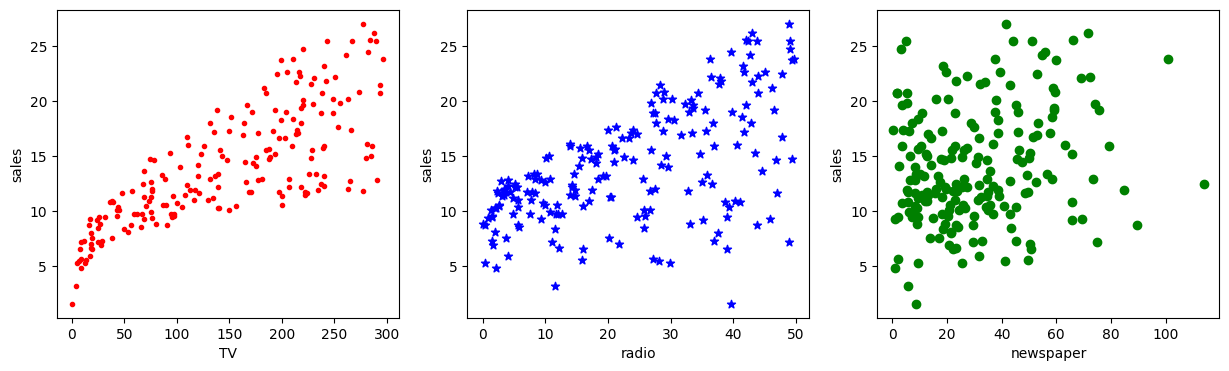

In [25]:
fig = plt.figure(figsize=(15,4))
gs = mpl.gridspec.GridSpec(1,3) #row * column

#plot of sales vs TV
ax = fig.add_subplot(gs[0])
ax.scatter(data_df["TV"], data_df["sales"], color = "red", marker = ".")
ax.set_xlabel("TV")
ax.set_ylabel("sales")

#plot of sales vs radio
ax = fig.add_subplot(gs[1])
ax.scatter(data_df["radio"], data_df["sales"], color = "blue", marker = "*")
ax.set_xlabel("radio")
ax.set_ylabel("sales")


#plot of sales vs newspaper
ax = fig.add_subplot(gs[2])
ax.scatter(data_df["newspaper"], data_df["sales"], color = "green", marker = "o")
ax.set_xlabel("newspaper")
ax.set_ylabel("sales")


In [26]:
X = data_df[["TV", "radio"]]
Y = data_df[["sales"]]

In [27]:
n_samples = X.shape[0]


In [28]:
n_samples

200

In [29]:
X = np.c_[np.ones((n_samples,1)), X]
X

array([[  1. , 230.1,  37.8],
       [  1. ,  44.5,  39.3],
       [  1. ,  17.2,  45.9],
       [  1. , 151.5,  41.3],
       [  1. , 180.8,  10.8],
       [  1. ,   8.7,  48.9],
       [  1. ,  57.5,  32.8],
       [  1. , 120.2,  19.6],
       [  1. ,   8.6,   2.1],
       [  1. , 199.8,   2.6],
       [  1. ,  66.1,   5.8],
       [  1. , 214.7,  24. ],
       [  1. ,  23.8,  35.1],
       [  1. ,  97.5,   7.6],
       [  1. , 204.1,  32.9],
       [  1. , 195.4,  47.7],
       [  1. ,  67.8,  36.6],
       [  1. , 281.4,  39.6],
       [  1. ,  69.2,  20.5],
       [  1. , 147.3,  23.9],
       [  1. , 218.4,  27.7],
       [  1. , 237.4,   5.1],
       [  1. ,  13.2,  15.9],
       [  1. , 228.3,  16.9],
       [  1. ,  62.3,  12.6],
       [  1. , 262.9,   3.5],
       [  1. , 142.9,  29.3],
       [  1. , 240.1,  16.7],
       [  1. , 248.8,  27.1],
       [  1. ,  70.6,  16. ],
       [  1. , 292.9,  28.3],
       [  1. , 112.9,  17.4],
       [  1. ,  97.2,   1.5],
       [  

In [30]:
X_transpose = np.transpose(X)

In [31]:
X_transpose

array([[  1. ,   1. ,   1. ,   1. ,   1. ,   1. ,   1. ,   1. ,   1. ,
          1. ,   1. ,   1. ,   1. ,   1. ,   1. ,   1. ,   1. ,   1. ,
          1. ,   1. ,   1. ,   1. ,   1. ,   1. ,   1. ,   1. ,   1. ,
          1. ,   1. ,   1. ,   1. ,   1. ,   1. ,   1. ,   1. ,   1. ,
          1. ,   1. ,   1. ,   1. ,   1. ,   1. ,   1. ,   1. ,   1. ,
          1. ,   1. ,   1. ,   1. ,   1. ,   1. ,   1. ,   1. ,   1. ,
          1. ,   1. ,   1. ,   1. ,   1. ,   1. ,   1. ,   1. ,   1. ,
          1. ,   1. ,   1. ,   1. ,   1. ,   1. ,   1. ,   1. ,   1. ,
          1. ,   1. ,   1. ,   1. ,   1. ,   1. ,   1. ,   1. ,   1. ,
          1. ,   1. ,   1. ,   1. ,   1. ,   1. ,   1. ,   1. ,   1. ,
          1. ,   1. ,   1. ,   1. ,   1. ,   1. ,   1. ,   1. ,   1. ,
          1. ,   1. ,   1. ,   1. ,   1. ,   1. ,   1. ,   1. ,   1. ,
          1. ,   1. ,   1. ,   1. ,   1. ,   1. ,   1. ,   1. ,   1. ,
          1. ,   1. ,   1. ,   1. ,   1. ,   1. ,   1. ,   1. ,   1. ,
      

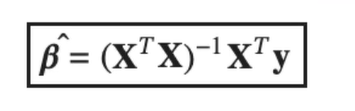

In [32]:
betas_tv_radio = np.linalg.inv(X_transpose.dot(X)).dot(X_transpose).dot(Y)

In [33]:
betas_tv_radio

array([[2.92109991],
       [0.04575482],
       [0.18799423]])

In [34]:
from IPython.display import display, HTML

message = """<strong>TV and Radio</strong> <br>
$y$ = {:.2f} + {:.2f}$x_{{1}}$ + {:.2f}$x_{{2}}$ <br>
$x_{{1}}$ = TV <br>
$x_{{2}}$ = radio
""".format(*betas_tv_radio[0], *betas_tv_radio[1], *betas_tv_radio[2])
display(HTML(message))
print("")

In [35]:
x = data_df[["TV", "radio", "newspaper"]]
y = data_df[["sales"]]

In [36]:
n_samples = x.shape[0]

In [37]:
n_samples

200

In [38]:
x = np.c_[np.ones((n_samples,1)), x]
x

array([[  1. , 230.1,  37.8,  69.2],
       [  1. ,  44.5,  39.3,  45.1],
       [  1. ,  17.2,  45.9,  69.3],
       [  1. , 151.5,  41.3,  58.5],
       [  1. , 180.8,  10.8,  58.4],
       [  1. ,   8.7,  48.9,  75. ],
       [  1. ,  57.5,  32.8,  23.5],
       [  1. , 120.2,  19.6,  11.6],
       [  1. ,   8.6,   2.1,   1. ],
       [  1. , 199.8,   2.6,  21.2],
       [  1. ,  66.1,   5.8,  24.2],
       [  1. , 214.7,  24. ,   4. ],
       [  1. ,  23.8,  35.1,  65.9],
       [  1. ,  97.5,   7.6,   7.2],
       [  1. , 204.1,  32.9,  46. ],
       [  1. , 195.4,  47.7,  52.9],
       [  1. ,  67.8,  36.6, 114. ],
       [  1. , 281.4,  39.6,  55.8],
       [  1. ,  69.2,  20.5,  18.3],
       [  1. , 147.3,  23.9,  19.1],
       [  1. , 218.4,  27.7,  53.4],
       [  1. , 237.4,   5.1,  23.5],
       [  1. ,  13.2,  15.9,  49.6],
       [  1. , 228.3,  16.9,  26.2],
       [  1. ,  62.3,  12.6,  18.3],
       [  1. , 262.9,   3.5,  19.5],
       [  1. , 142.9,  29.3,  12.6],
 

In [39]:
X_transpose = np.transpose(x)

In [40]:
X_transpose

array([[  1. ,   1. ,   1. ,   1. ,   1. ,   1. ,   1. ,   1. ,   1. ,
          1. ,   1. ,   1. ,   1. ,   1. ,   1. ,   1. ,   1. ,   1. ,
          1. ,   1. ,   1. ,   1. ,   1. ,   1. ,   1. ,   1. ,   1. ,
          1. ,   1. ,   1. ,   1. ,   1. ,   1. ,   1. ,   1. ,   1. ,
          1. ,   1. ,   1. ,   1. ,   1. ,   1. ,   1. ,   1. ,   1. ,
          1. ,   1. ,   1. ,   1. ,   1. ,   1. ,   1. ,   1. ,   1. ,
          1. ,   1. ,   1. ,   1. ,   1. ,   1. ,   1. ,   1. ,   1. ,
          1. ,   1. ,   1. ,   1. ,   1. ,   1. ,   1. ,   1. ,   1. ,
          1. ,   1. ,   1. ,   1. ,   1. ,   1. ,   1. ,   1. ,   1. ,
          1. ,   1. ,   1. ,   1. ,   1. ,   1. ,   1. ,   1. ,   1. ,
          1. ,   1. ,   1. ,   1. ,   1. ,   1. ,   1. ,   1. ,   1. ,
          1. ,   1. ,   1. ,   1. ,   1. ,   1. ,   1. ,   1. ,   1. ,
          1. ,   1. ,   1. ,   1. ,   1. ,   1. ,   1. ,   1. ,   1. ,
          1. ,   1. ,   1. ,   1. ,   1. ,   1. ,   1. ,   1. ,   1. ,
      

In [41]:
betas_tv_radio_newspaper = np.linalg.inv(X_transpose.dot(x)).dot(X_transpose).dot(y)

In [42]:
betas_tv_radio_newspaper

array([[ 2.93888937e+00],
       [ 4.57646455e-02],
       [ 1.88530017e-01],
       [-1.03749304e-03]])

In [43]:
from sklearn.linear_model import LinearRegression

In [44]:
X = data_df[["TV", "radio", "newspaper"]].to_numpy()
Y = data_df[["sales"]].to_numpy()

In [45]:
from sklearn.model_selection import train_test_split

In [46]:
linear_reg= LinearRegression()

In [47]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [48]:
X_train.shape, X_test.shape, Y_train.shape, Y_test.shape

((160, 3), (40, 3), (160, 1), (40, 1))

In [49]:
linear_reg.fit(X_train, Y_train)

LinearRegression()

In [50]:
linear_reg.coef_

array([[0.04472952, 0.18919505, 0.00276111]])

In [51]:
linear_reg.intercept_

array([2.97906734])

In [52]:
y_pred = linear_reg.predict(X_test)

In [53]:
y_pred.shape

(40, 1)

In [54]:
SSE = np.sum(np.power((Y_test - y_pred),2))

In [55]:
SSE

np.float64(126.96389415904417)

In [56]:
from sklearn.metrics import r2_score

In [57]:
r2_score(Y_test, y_pred)

0.899438024100912

In [58]:
from sklearn.metrics import mean_squared_error

In [59]:
mean_squared_error(Y_test, y_pred)

3.174097353976104

## Potential Issues with Ordinary Least Squares

We derived OLS for both simple and multiple linear regression. In both cases, OLS finds the parameter estimates that minimize the SSE. However, the derivation relies on a few assumptions — violating them can create serious problems.

### 1. Existence of $(\mathbf{X}^T \mathbf{X})^{-1}$

While calculating $\hat{\boldsymbol{\beta}}$, we assume $(\mathbf{X}^T \mathbf{X})^{-1}$ exists.

**When does it fail to exist?** The inverse doesn't exist when $\mathbf{X}^T \mathbf{X}$ is **not full rank**. Since $\mathbf{X}$ has dimension $n \times (d+1)$, it needs at least $(d+1)$ linearly independent rows to be full rank.

If there's **perfect collinearity** between any two independent (input) variables, $\mathbf{X}^T \mathbf{X}$ won't be full rank, and the inverse doesn't exist. In other words: there should be correlation between the *dependent* (output) and *independent* (input) variables, but the independent variables should be independent of **each other**.

### 2. Existence of $n \gg d$

If $n < d + 1$, we can't perform least squares — infinitely many solutions exist when the number of data points is less than the number of features. We need **more observations than features**.

---

There's another parameter-estimation method, **Gradient Descent**, which addresses these limitations of OLS. That's the topic for the next chapter.

In [60]:
# A full rank matrix is a matrix whose rank equals the highest possible value for its specific dimensions.